# Câu 1: Thay đổi số lượng epoch

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 1. Tải dữ liệu MNIST
transform = transforms.ToTensor()  # Chuyển ảnh thành tensor
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)
# 2. Định nghĩa mô hình CNN
class MNIST_CNN(nn.Module):  # Tạo lớp MNIST_CNN kế thừa từ nn.Module (lớp cơ bản của PyTorch)
    def __init__(self):  # Hàm khởi tạo mô hình
        super(MNIST_CNN, self).__init__()  # Gọi hàm khởi tạo của lớp cha (nn.Module)
        # Tầng tích chập 1: 1 kênh đầu vào (ảnh đen trắng) -> 16 kênh đầu ra, filter 3x3
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)  # Tích chập giảm kích thước từ 28x28 -> 26x26
        # Tầng tích chập 2: 16 kênh đầu vào -> 32 kênh đầu ra, filter 3x3
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # Tích chập giảm từ 12x12 -> 10x10 (sau pooling)
        # Tầng pooling: vùng 2x2, giảm kích thước một nửa
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # Ví dụ: 26x26 -> 13x13, 10x10 -> 5x5
        # Tầng fully connected: từ 32 kênh * 5x5 (800) -> 10 lớp (0-9)
        self.fc1 = nn.Linear(32 * 5 * 5, 10)  # Duỗi feature map thành vector rồi phân loại

    def forward(self, x):  # Hàm forward định nghĩa luồng dữ liệu qua các tầng
        x = self.pool(torch.relu(self.conv1(x)))  # Conv1 -> ReLU (loại giá trị âm) -> Pool (giảm kích thước)
        x = self.pool(torch.relu(self.conv2(x)))  # Conv2 -> ReLU -> Pool, cuối cùng ra 32x5x5
        x = x.view(-1, 32 * 5 * 5)  # Duỗi tensor thành vector, -1 tự động tính batch size
        x = self.fc1(x)  # Qua tầng fully connected, ra 10 giá trị (logits cho 0-9)
        return x  # Trả về kết quả dự đoán
# Khởi tạo mô hình
model = MNIST_CNN()  # Tạo một instance của lớp MNIST_CNN
criterion = nn.CrossEntropyLoss()  # Định nghĩa hàm mất mát CrossEntropy (dùng cho phân loại nhiều lớp)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)  # Dùng SGD với learning rate 0.01 và momentum 0.9 để tối ưu
# 3. Huấn luyện mô hình
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Chọn GPU nếu có, không thì dùng CPU
model.to(device)  # Chuyển mô hình sang thiết bị đã chọn (GPU/CPU)

# Tạo hai danh sách để lưu giá trị mất mát (loss) và độ chính xác (accuracy) qua từng epoch
loss_values = []  # Lưu mất mát trung bình của mỗi epoch để theo dõi quá trình huấn luyện
accuracy_values = []  # Lưu độ chính xác trung bình của mỗi epoch để đánh giá hiệu quả mô hình

# Huấn luyện mô hình qua 10 epoch (mỗi epoch là một lần duyệt qua toàn bộ dữ liệu huấn luyện)
for epoch in range(10):  # Lặp 10 lần, mỗi lần xử lý toàn bộ tập dữ liệu
    # Khởi tạo biến để theo dõi tổng mất mát trong epoch này
    running_loss = 0.0  # Biến này cộng dồn mất mát của các batch để tính trung bình sau
    # Khởi tạo biến để tính độ chính xác
    correct = 0  # Đếm số dự đoán đúng trong epoch
    total = 0  # Đếm tổng số mẫu được dự đoán trong epoch
    
    # Lặp qua từng batch (nhóm 64 ảnh) trong tập huấn luyện (train_loader)
    for images, labels in train_loader:  # images: tensor chứa 64 ảnh, labels: tensor chứa 64 nhãn (0-9)
        # Chuyển ảnh và nhãn sang thiết bị (GPU/CPU) để đồng bộ với mô hình
        images, labels = images.to(device), labels.to(device)  # Đảm bảo dữ liệu và mô hình cùng thiết bị
        
        # Xóa gradient cũ từ bước trước để tránh tích lũy
        optimizer.zero_grad()  # Gradient phải được đặt về 0 trước khi tính gradient mới
        # Đưa ảnh qua mô hình để nhận dự đoán (outputs là tensor chứa logits cho 10 lớp)
        outputs = model(images)  # Mô hình xử lý ảnh và trả về dự đoán
        # Tính mất mát (loss) bằng cách so sánh dự đoán (outputs) với nhãn thật (labels)
        loss = criterion(outputs, labels)  # Hàm CrossEntropyLoss đo lường sai lệch giữa dự đoán và thực tế
        # Tính gradient ngược (backpropagation) để tìm hướng tối ưu hóa trọng số
        loss.backward()  # Gradient được tính cho tất cả tham số của mô hình
        # Cập nhật trọng số của mô hình dựa trên gradient, sử dụng thuật toán SGD
        optimizer.step()  # Điều chỉnh trọng số để giảm mất mát ở bước tiếp theo
        
        # Cộng dồn giá trị mất mát của batch này (loss.item() trả về giá trị số của loss)
        running_loss += loss.item()  # Tổng hợp mất mát để tính trung bình sau
        
        # Tính độ chính xác cho batch này
        # Lấy nhãn dự đoán bằng cách chọn lớp có giá trị logits cao nhất
        _, predicted = torch.max(outputs.data, 1)  # predicted chứa nhãn dự đoán (0-9) cho 64 ảnh
        # Cộng dồn số mẫu trong batch (thường là 64, trừ batch cuối có thể ít hơn)
        total += labels.size(0)  # Tổng số ảnh đã xử lý
        # Đếm số dự đoán đúng bằng cách so sánh predicted với labels
        correct += (predicted == labels).sum().item()  # Số dự đoán đúng trong batch
    
    # Tính mất mát trung bình cho epoch bằng cách chia tổng mất mát cho số batch
    epoch_loss = running_loss / len(train_loader)  # Trung bình mất mát của tất cả batch
    # Tính độ chính xác trung bình (phần trăm) cho epoch
    epoch_accuracy = 100 * correct / total  # Tỷ lệ dự đoán đúng trên tổng số mẫu
    # Lưu giá trị mất mát và độ chính xác để vẽ biểu đồ sau này
    loss_values.append(epoch_loss)  # Thêm mất mát trung bình vào danh sách
    accuracy_values.append(epoch_accuracy)  # Thêm độ chính xác vào danh sách
    # In kết quả sau mỗi epoch để theo dõi tiến trình huấn luyện
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")  # Hiển thị mất mát và độ chính xác

Epoch 1, Loss: 0.2651, Accuracy: 91.77%
Epoch 2, Loss: 0.0815, Accuracy: 97.51%
Epoch 3, Loss: 0.0631, Accuracy: 98.10%
Epoch 4, Loss: 0.0532, Accuracy: 98.42%
Epoch 5, Loss: 0.0479, Accuracy: 98.51%
Epoch 6, Loss: 0.0421, Accuracy: 98.69%
Epoch 7, Loss: 0.0393, Accuracy: 98.77%
Epoch 8, Loss: 0.0357, Accuracy: 98.93%
Epoch 9, Loss: 0.0326, Accuracy: 98.98%
Epoch 10, Loss: 0.0312, Accuracy: 99.02%


### 1. Độ chính xác trên tập test
Độ chính xác tăng nhẹ khi tăng số epoch.
* Sau 5 epoch: khoảng 98.51%
* Sau 10 epoch: khoảng 99.02%
Điều này cho thấy mô hình tiếp tục học thêm các đặc trưng của dữ liệu khi được huấn luyện lâu hơn.
### 2. Sự thay đổi của loss qua 10 epoch
Giá trị loss giảm dần theo từng epoch:
* Ban đầu giảm rất nhanh (Epoch 1 → Epoch 3).
* Sau đó giảm chậm dần từ Epoch 6 trở đi.
* Đến gần Epoch 10, loss bắt đầu chững lại.
Xu hướng này cho thấy mô hình đang dần hội tụ (converge).
### 3. Vì sao số epoch ảnh hưởng đến kết quả
Epoch là số lần mô hình học qua toàn bộ tập dữ liệu huấn luyện.
* Khi epoch ít, mô hình chưa học đủ → kết quả chưa tối ưu.
* Khi tăng epoch, mô hình có nhiều cơ hội điều chỉnh trọng số → dự đoán chính xác hơn.
* Tuy nhiên nếu epoch quá lớn, mô hình có thể bị overfitting (học quá sát dữ liệu huấn luyện và giảm khả năng dự đoán trên dữ liệu mới).
Việc tăng từ 5 lên 10 epoch giúp mô hình học tốt hơn, thể hiện qua loss giảm và accuracy tăng nhẹ.

# Câu 2: Thêm một tầng tích chập

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 1. Tải dữ liệu MNIST
transform = transforms.ToTensor()  # Chuyển ảnh thành tensor
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)
# 2. Định nghĩa mô hình CNN
class MNIST_CNN(nn.Module):  # Tạo lớp MNIST_CNN kế thừa từ nn.Module (lớp cơ bản của PyTorch)
    def __init__(self):  # Hàm khởi tạo mô hình
        super(MNIST_CNN, self).__init__()  # Gọi hàm khởi tạo của lớp cha (nn.Module)
        # Tầng tích chập 1: 1 kênh đầu vào (ảnh đen trắng) -> 16 kênh đầu ra, filter 3x3
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)  # Tích chập giảm kích thước từ 28x28 -> 26x26
        # Tầng tích chập 2: 16 kênh đầu vào -> 32 kênh đầu ra, filter 3x3
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # Tích chập giảm từ 12x12 -> 10x10 (sau pooling)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=0) 
        # Tầng pooling: vùng 2x2, giảm kích thước một nửa
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # Ví dụ: 26x26 -> 13x13, 10x10 -> 5x5
        # Tầng fully connected: từ 32 kênh * 5x5 (800) -> 10 lớp (0-9)
        self.fc1 = nn.Linear(64 * 1 * 1, 10)  # Duỗi feature map thành vector rồi phân loại

    def forward(self, x):  # Hàm forward định nghĩa luồng dữ liệu qua các tầng
        x = self.pool(torch.relu(self.conv1(x)))  # Conv1 -> ReLU (loại giá trị âm) -> Pool (giảm kích thước)
        x = self.pool(torch.relu(self.conv2(x)))  # Conv2 -> ReLU -> Pool, cuối cùng ra 32x5x5
        x = self.pool(torch.relu(self.conv3(x)))
        x = x.view(-1, 64 * 1 * 1)  # Duỗi tensor thành vector, -1 tự động tính batch size
        x = self.fc1(x)  # Qua tầng fully connected, ra 10 giá trị (logits cho 0-9)
        return x  # Trả về kết quả dự đoán
# Khởi tạo mô hình
model = MNIST_CNN()  # Tạo một instance của lớp MNIST_CNN
criterion = nn.CrossEntropyLoss()  # Định nghĩa hàm mất mát CrossEntropy (dùng cho phân loại nhiều lớp)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)  # Dùng SGD với learning rate 0.01 và momentum 0.9 để tối ưu
# 3. Huấn luyện mô hình
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Chọn GPU nếu có, không thì dùng CPU
model.to(device)  # Chuyển mô hình sang thiết bị đã chọn (GPU/CPU)

# Tạo hai danh sách để lưu giá trị mất mát (loss) và độ chính xác (accuracy) qua từng epoch
loss_values = []  # Lưu mất mát trung bình của mỗi epoch để theo dõi quá trình huấn luyện
accuracy_values = []  # Lưu độ chính xác trung bình của mỗi epoch để đánh giá hiệu quả mô hình

# Huấn luyện mô hình qua 10 epoch (mỗi epoch là một lần duyệt qua toàn bộ dữ liệu huấn luyện)
for epoch in range(10):  # Lặp 10 lần, mỗi lần xử lý toàn bộ tập dữ liệu
    # Khởi tạo biến để theo dõi tổng mất mát trong epoch này
    running_loss = 0.0  # Biến này cộng dồn mất mát của các batch để tính trung bình sau
    # Khởi tạo biến để tính độ chính xác
    correct = 0  # Đếm số dự đoán đúng trong epoch
    total = 0  # Đếm tổng số mẫu được dự đoán trong epoch
    
    # Lặp qua từng batch (nhóm 64 ảnh) trong tập huấn luyện (train_loader)
    for images, labels in train_loader:  # images: tensor chứa 64 ảnh, labels: tensor chứa 64 nhãn (0-9)
        # Chuyển ảnh và nhãn sang thiết bị (GPU/CPU) để đồng bộ với mô hình
        images, labels = images.to(device), labels.to(device)  # Đảm bảo dữ liệu và mô hình cùng thiết bị
        
        # Xóa gradient cũ từ bước trước để tránh tích lũy
        optimizer.zero_grad()  # Gradient phải được đặt về 0 trước khi tính gradient mới
        # Đưa ảnh qua mô hình để nhận dự đoán (outputs là tensor chứa logits cho 10 lớp)
        outputs = model(images)  # Mô hình xử lý ảnh và trả về dự đoán
        # Tính mất mát (loss) bằng cách so sánh dự đoán (outputs) với nhãn thật (labels)
        loss = criterion(outputs, labels)  # Hàm CrossEntropyLoss đo lường sai lệch giữa dự đoán và thực tế
        # Tính gradient ngược (backpropagation) để tìm hướng tối ưu hóa trọng số
        loss.backward()  # Gradient được tính cho tất cả tham số của mô hình
        # Cập nhật trọng số của mô hình dựa trên gradient, sử dụng thuật toán SGD
        optimizer.step()  # Điều chỉnh trọng số để giảm mất mát ở bước tiếp theo
        
        # Cộng dồn giá trị mất mát của batch này (loss.item() trả về giá trị số của loss)
        running_loss += loss.item()  # Tổng hợp mất mát để tính trung bình sau
        
        # Tính độ chính xác cho batch này
        # Lấy nhãn dự đoán bằng cách chọn lớp có giá trị logits cao nhất
        _, predicted = torch.max(outputs.data, 1)  # predicted chứa nhãn dự đoán (0-9) cho 64 ảnh
        # Cộng dồn số mẫu trong batch (thường là 64, trừ batch cuối có thể ít hơn)
        total += labels.size(0)  # Tổng số ảnh đã xử lý
        # Đếm số dự đoán đúng bằng cách so sánh predicted với labels
        correct += (predicted == labels).sum().item()  # Số dự đoán đúng trong batch
    
    # Tính mất mát trung bình cho epoch bằng cách chia tổng mất mát cho số batch
    epoch_loss = running_loss / len(train_loader)  # Trung bình mất mát của tất cả batch
    # Tính độ chính xác trung bình (phần trăm) cho epoch
    epoch_accuracy = 100 * correct / total  # Tỷ lệ dự đoán đúng trên tổng số mẫu
    # Lưu giá trị mất mát và độ chính xác để vẽ biểu đồ sau này
    loss_values.append(epoch_loss)  # Thêm mất mát trung bình vào danh sách
    accuracy_values.append(epoch_accuracy)  # Thêm độ chính xác vào danh sách
    # In kết quả sau mỗi epoch để theo dõi tiến trình huấn luyện
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")  # Hiển thị mất mát và độ chính xác

Epoch 1, Loss: 0.4787, Accuracy: 84.43%
Epoch 2, Loss: 0.1161, Accuracy: 96.39%
Epoch 3, Loss: 0.0832, Accuracy: 97.39%
Epoch 4, Loss: 0.0679, Accuracy: 97.94%
Epoch 5, Loss: 0.0570, Accuracy: 98.19%
Epoch 6, Loss: 0.0495, Accuracy: 98.49%
Epoch 7, Loss: 0.0437, Accuracy: 98.63%
Epoch 8, Loss: 0.0405, Accuracy: 98.72%
Epoch 9, Loss: 0.0356, Accuracy: 98.85%
Epoch 10, Loss: 0.0327, Accuracy: 98.95%


Sau 10 epoch, mô hình đạt độ chính xác khoảng 98.95%.
So với mô hình ban đầu (khoảng 99.02%), độ chính xác gần tương đương nhưng hơi thấp hơn một chút.

Điều này cho thấy việc thêm một tầng tích chập không luôn luôn đảm bảo cải thiện độ chính xác, đặc biệt khi mô hình ban đầu đã học khá tốt.

Loss giảm dần qua các epoch:

- Ban đầu loss khá cao (0.4787) vì mô hình mới có nhiều tham số hơn.
- Sau vài epoch, loss giảm nhanh khi mô hình bắt đầu học được đặc trưng của dữ liệu.
- Từ epoch 6 trở đi, loss giảm chậm dần và bắt đầu hội tụ.

Việc thêm tầng tích chập giúp mô hình có khả năng học các đặc trưng phức tạp hơn của ảnh. Tuy nhiên trong bài toán MNIST, mô hình ban đầu đã đủ mạnh nên việc thêm tầng tích chập chỉ mang lại sự cải thiện nhỏ hoặc gần như tương đương về độ chính xác.

# Câu 3: Thay đổi learning rate

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 1. Tải dữ liệu MNIST
transform = transforms.ToTensor()  # Chuyển ảnh thành tensor
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)
# 2. Định nghĩa mô hình CNN
class MNIST_CNN(nn.Module):  # Tạo lớp MNIST_CNN kế thừa từ nn.Module (lớp cơ bản của PyTorch)
    def __init__(self):  # Hàm khởi tạo mô hình
        super(MNIST_CNN, self).__init__()  # Gọi hàm khởi tạo của lớp cha (nn.Module)
        # Tầng tích chập 1: 1 kênh đầu vào (ảnh đen trắng) -> 16 kênh đầu ra, filter 3x3
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)  # Tích chập giảm kích thước từ 28x28 -> 26x26
        # Tầng tích chập 2: 16 kênh đầu vào -> 32 kênh đầu ra, filter 3x3
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # Tích chập giảm từ 12x12 -> 10x10 (sau pooling)
        # Tầng pooling: vùng 2x2, giảm kích thước một nửa
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # Ví dụ: 26x26 -> 13x13, 10x10 -> 5x5
        # Tầng fully connected: từ 32 kênh * 5x5 (800) -> 10 lớp (0-9)
        self.fc1 = nn.Linear(32 * 5 * 5, 10)  # Duỗi feature map thành vector rồi phân loại

    def forward(self, x):  # Hàm forward định nghĩa luồng dữ liệu qua các tầng
        x = self.pool(torch.relu(self.conv1(x)))  # Conv1 -> ReLU (loại giá trị âm) -> Pool (giảm kích thước)
        x = self.pool(torch.relu(self.conv2(x)))  # Conv2 -> ReLU -> Pool, cuối cùng ra 32x5x5
        x = x.view(-1, 32 * 5 * 5)  # Duỗi tensor thành vector, -1 tự động tính batch size
        x = self.fc1(x)  # Qua tầng fully connected, ra 10 giá trị (logits cho 0-9)
        return x  # Trả về kết quả dự đoán
# Khởi tạo mô hình
model = MNIST_CNN()  # Tạo một instance của lớp MNIST_CNN
criterion = nn.CrossEntropyLoss()  # Định nghĩa hàm mất mát CrossEntropy (dùng cho phân loại nhiều lớp)
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)  # Dùng SGD với learning rate 0.01 và momentum 0.9 để tối ưu
# 3. Huấn luyện mô hình
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Chọn GPU nếu có, không thì dùng CPU
model.to(device)  # Chuyển mô hình sang thiết bị đã chọn (GPU/CPU)

# Tạo hai danh sách để lưu giá trị mất mát (loss) và độ chính xác (accuracy) qua từng epoch
loss_values = []  # Lưu mất mát trung bình của mỗi epoch để theo dõi quá trình huấn luyện
accuracy_values = []  # Lưu độ chính xác trung bình của mỗi epoch để đánh giá hiệu quả mô hình

# Huấn luyện mô hình qua 10 epoch (mỗi epoch là một lần duyệt qua toàn bộ dữ liệu huấn luyện)
for epoch in range(10):  # Lặp 10 lần, mỗi lần xử lý toàn bộ tập dữ liệu
    # Khởi tạo biến để theo dõi tổng mất mát trong epoch này
    running_loss = 0.0  # Biến này cộng dồn mất mát của các batch để tính trung bình sau
    # Khởi tạo biến để tính độ chính xác
    correct = 0  # Đếm số dự đoán đúng trong epoch
    total = 0  # Đếm tổng số mẫu được dự đoán trong epoch
    
    # Lặp qua từng batch (nhóm 64 ảnh) trong tập huấn luyện (train_loader)
    for images, labels in train_loader:  # images: tensor chứa 64 ảnh, labels: tensor chứa 64 nhãn (0-9)
        # Chuyển ảnh và nhãn sang thiết bị (GPU/CPU) để đồng bộ với mô hình
        images, labels = images.to(device), labels.to(device)  # Đảm bảo dữ liệu và mô hình cùng thiết bị
        
        # Xóa gradient cũ từ bước trước để tránh tích lũy
        optimizer.zero_grad()  # Gradient phải được đặt về 0 trước khi tính gradient mới
        # Đưa ảnh qua mô hình để nhận dự đoán (outputs là tensor chứa logits cho 10 lớp)
        outputs = model(images)  # Mô hình xử lý ảnh và trả về dự đoán
        # Tính mất mát (loss) bằng cách so sánh dự đoán (outputs) với nhãn thật (labels)
        loss = criterion(outputs, labels)  # Hàm CrossEntropyLoss đo lường sai lệch giữa dự đoán và thực tế
        # Tính gradient ngược (backpropagation) để tìm hướng tối ưu hóa trọng số
        loss.backward()  # Gradient được tính cho tất cả tham số của mô hình
        # Cập nhật trọng số của mô hình dựa trên gradient, sử dụng thuật toán SGD
        optimizer.step()  # Điều chỉnh trọng số để giảm mất mát ở bước tiếp theo
        
        # Cộng dồn giá trị mất mát của batch này (loss.item() trả về giá trị số của loss)
        running_loss += loss.item()  # Tổng hợp mất mát để tính trung bình sau
        
        # Tính độ chính xác cho batch này
        # Lấy nhãn dự đoán bằng cách chọn lớp có giá trị logits cao nhất
        _, predicted = torch.max(outputs.data, 1)  # predicted chứa nhãn dự đoán (0-9) cho 64 ảnh
        # Cộng dồn số mẫu trong batch (thường là 64, trừ batch cuối có thể ít hơn)
        total += labels.size(0)  # Tổng số ảnh đã xử lý
        # Đếm số dự đoán đúng bằng cách so sánh predicted với labels
        correct += (predicted == labels).sum().item()  # Số dự đoán đúng trong batch
    
    # Tính mất mát trung bình cho epoch bằng cách chia tổng mất mát cho số batch
    epoch_loss = running_loss / len(train_loader)  # Trung bình mất mát của tất cả batch
    # Tính độ chính xác trung bình (phần trăm) cho epoch
    epoch_accuracy = 100 * correct / total  # Tỷ lệ dự đoán đúng trên tổng số mẫu
    # Lưu giá trị mất mát và độ chính xác để vẽ biểu đồ sau này
    loss_values.append(epoch_loss)  # Thêm mất mát trung bình vào danh sách
    accuracy_values.append(epoch_accuracy)  # Thêm độ chính xác vào danh sách
    # In kết quả sau mỗi epoch để theo dõi tiến trình huấn luyện
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")  # Hiển thị mất mát và độ chính xác

Epoch 1, Loss: 0.1426, Accuracy: 95.58%
Epoch 2, Loss: 0.0562, Accuracy: 98.24%
Epoch 3, Loss: 0.0470, Accuracy: 98.52%
Epoch 4, Loss: 0.0394, Accuracy: 98.77%
Epoch 5, Loss: 0.0344, Accuracy: 98.92%
Epoch 6, Loss: 0.0300, Accuracy: 99.06%
Epoch 7, Loss: 0.0291, Accuracy: 99.06%
Epoch 8, Loss: 0.0249, Accuracy: 99.27%
Epoch 9, Loss: 0.0238, Accuracy: 99.22%
Epoch 10, Loss: 0.0242, Accuracy: 99.22%


#### Learning rate 0.001
Epoch 1, Loss: 0.9808, Accuracy: 73.43% <br>
Epoch 2, Loss: 0.2761, Accuracy: 91.76% <br>
Epoch 3, Loss: 0.1949, Accuracy: 94.23% <br>
Epoch 4, Loss: 0.1533, Accuracy: 95.50% <br>
Epoch 5, Loss: 0.1291, Accuracy: 96.17% <br>
Epoch 6, Loss: 0.1132, Accuracy: 96.67% <br>
Epoch 7, Loss: 0.1015, Accuracy: 97.01% <br>
Epoch 8, Loss: 0.0924, Accuracy: 97.27% <br>
Epoch 9, Loss: 0.0862, Accuracy: 97.41% <br>
Epoch 10, Loss: 0.0807, Accuracy: 97.56% 
Nhận xét:
- Loss giảm từ từ và ổn định qua các epoch.
- Accuracy tăng chậm và sau 10 epoch đạt khoảng 97.56%.
- Mô hình học ổn định nhưng khá chậm do learning rate nhỏ.
### Learning rate 0.1
Epoch 1, Loss: 0.1426, Accuracy: 95.58% <br>
Epoch 2, Loss: 0.0562, Accuracy: 98.24% <br>
Epoch 3, Loss: 0.0470, Accuracy: 98.52% <br>
Epoch 4, Loss: 0.0394, Accuracy: 98.77% <br>
Epoch 5, Loss: 0.0344, Accuracy: 98.92% <br>
Epoch 6, Loss: 0.0300, Accuracy: 99.06% <br>
Epoch 7, Loss: 0.0291, Accuracy: 99.06% <br>
Epoch 8, Loss: 0.0249, Accuracy: 99.27% <br>
Epoch 9, Loss: 0.0238, Accuracy: 99.22% <br>
Epoch 10, Loss: 0.0242, Accuracy: 99.22%
Nhận xét:
- Loss giảm rất nhanh chỉ sau vài epoch.
- Accuracy tăng nhanh và đạt khoảng 99.22% sau 10 epoch.
- Từ epoch 6 trở đi, loss dao động nhẹ, cho thấy mô hình đã gần hội tụ.

Learning Rate	    Accuracy cuối	    Đặc điểm
0.001	            97.56%              Học chậm nhưng ổn định
0.1	                99.22%          	Học nhanh, hội tụ nhanh

Learning rate lớn giúp mô hình cập nhật trọng số mạnh hơn, do đó học nhanh hơn. Tuy nhiên nếu quá lớn có thể gây dao động mạnh hoặc không hội tụ.

Learning rate quyết định bước cập nhật trọng số trong quá trình tối ưu:
* Learning rate nhỏ
    - Cập nhật trọng số rất nhỏ
    - Mô hình học chậm nhưng ổn định
* Learning rate lớn
    - Cập nhật trọng số mạnh hơn
    - Mô hình học nhanh hơn nhưng dễ dao động

# Câu 4: Vẽ thêm feature map từ tầng tích chập thứ hai

Epoch 1, Loss: 0.2954, Accuracy: 90.86%
Epoch 2, Loss: 0.0835, Accuracy: 97.47%
Epoch 3, Loss: 0.0647, Accuracy: 97.98%
Epoch 4, Loss: 0.0545, Accuracy: 98.39%
Epoch 5, Loss: 0.0473, Accuracy: 98.52%
Epoch 6, Loss: 0.0431, Accuracy: 98.67%
Epoch 7, Loss: 0.0396, Accuracy: 98.75%
Epoch 8, Loss: 0.0355, Accuracy: 98.89%
Epoch 9, Loss: 0.0329, Accuracy: 98.99%
Epoch 10, Loss: 0.0308, Accuracy: 99.00%
Độ chính xác trên tập test: 98.90%


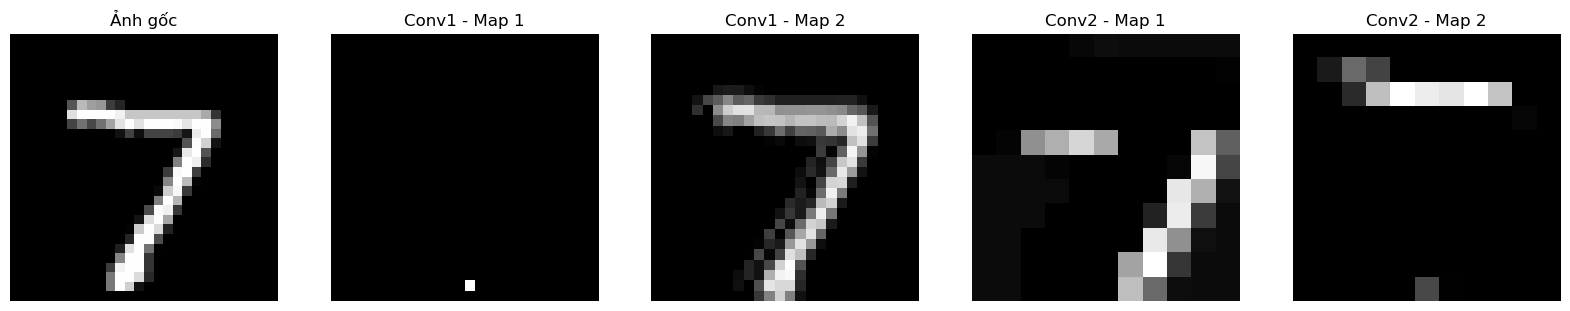

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# 1. Tải dữ liệu MNIST
transform = transforms.ToTensor()  # Chuyển ảnh thành tensor
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)
# 2. Định nghĩa mô hình CNN
class MNIST_CNN(nn.Module):  # Tạo lớp MNIST_CNN kế thừa từ nn.Module (lớp cơ bản của PyTorch)
    def __init__(self):  # Hàm khởi tạo mô hình
        super(MNIST_CNN, self).__init__()  # Gọi hàm khởi tạo của lớp cha (nn.Module)
        # Tầng tích chập 1: 1 kênh đầu vào (ảnh đen trắng) -> 16 kênh đầu ra, filter 3x3
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)  # Tích chập giảm kích thước từ 28x28 -> 26x26
        # Tầng tích chập 2: 16 kênh đầu vào -> 32 kênh đầu ra, filter 3x3
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # Tích chập giảm từ 12x12 -> 10x10 (sau pooling)
        # Tầng pooling: vùng 2x2, giảm kích thước một nửa
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # Ví dụ: 26x26 -> 13x13, 10x10 -> 5x5
        # Tầng fully connected: từ 32 kênh * 5x5 (800) -> 10 lớp (0-9)
        self.fc1 = nn.Linear(32 * 5 * 5, 10)  # Duỗi feature map thành vector rồi phân loại

    def forward(self, x):  # Hàm forward định nghĩa luồng dữ liệu qua các tầng
        x = self.pool(torch.relu(self.conv1(x)))  # Conv1 -> ReLU (loại giá trị âm) -> Pool (giảm kích thước)
        x = self.pool(torch.relu(self.conv2(x)))  # Conv2 -> ReLU -> Pool, cuối cùng ra 32x5x5
        x = x.view(-1, 32 * 5 * 5)  # Duỗi tensor thành vector, -1 tự động tính batch size
        x = self.fc1(x)  # Qua tầng fully connected, ra 10 giá trị (logits cho 0-9)
        return x  # Trả về kết quả dự đoán
# Khởi tạo mô hình
model = MNIST_CNN()  # Tạo một instance của lớp MNIST_CNN
criterion = nn.CrossEntropyLoss()  # Định nghĩa hàm mất mát CrossEntropy (dùng cho phân loại nhiều lớp)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)  # Dùng SGD với learning rate 0.01 và momentum 0.9 để tối ưu
# 3. Huấn luyện mô hình
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Chọn GPU nếu có, không thì dùng CPU
model.to(device)  # Chuyển mô hình sang thiết bị đã chọn (GPU/CPU)

# Tạo hai danh sách để lưu giá trị mất mát (loss) và độ chính xác (accuracy) qua từng epoch
loss_values = []  # Lưu mất mát trung bình của mỗi epoch để theo dõi quá trình huấn luyện
accuracy_values = []  # Lưu độ chính xác trung bình của mỗi epoch để đánh giá hiệu quả mô hình

# Huấn luyện mô hình qua 10 epoch (mỗi epoch là một lần duyệt qua toàn bộ dữ liệu huấn luyện)
for epoch in range(10):  # Lặp 10 lần, mỗi lần xử lý toàn bộ tập dữ liệu
    # Khởi tạo biến để theo dõi tổng mất mát trong epoch này
    running_loss = 0.0  # Biến này cộng dồn mất mát của các batch để tính trung bình sau
    # Khởi tạo biến để tính độ chính xác
    correct = 0  # Đếm số dự đoán đúng trong epoch
    total = 0  # Đếm tổng số mẫu được dự đoán trong epoch
    
    # Lặp qua từng batch (nhóm 64 ảnh) trong tập huấn luyện (train_loader)
    for images, labels in train_loader:  # images: tensor chứa 64 ảnh, labels: tensor chứa 64 nhãn (0-9)
        # Chuyển ảnh và nhãn sang thiết bị (GPU/CPU) để đồng bộ với mô hình
        images, labels = images.to(device), labels.to(device)  # Đảm bảo dữ liệu và mô hình cùng thiết bị
        
        # Xóa gradient cũ từ bước trước để tránh tích lũy
        optimizer.zero_grad()  # Gradient phải được đặt về 0 trước khi tính gradient mới
        # Đưa ảnh qua mô hình để nhận dự đoán (outputs là tensor chứa logits cho 10 lớp)
        outputs = model(images)  # Mô hình xử lý ảnh và trả về dự đoán
        # Tính mất mát (loss) bằng cách so sánh dự đoán (outputs) với nhãn thật (labels)
        loss = criterion(outputs, labels)  # Hàm CrossEntropyLoss đo lường sai lệch giữa dự đoán và thực tế
        # Tính gradient ngược (backpropagation) để tìm hướng tối ưu hóa trọng số
        loss.backward()  # Gradient được tính cho tất cả tham số của mô hình
        # Cập nhật trọng số của mô hình dựa trên gradient, sử dụng thuật toán SGD
        optimizer.step()  # Điều chỉnh trọng số để giảm mất mát ở bước tiếp theo
        
        # Cộng dồn giá trị mất mát của batch này (loss.item() trả về giá trị số của loss)
        running_loss += loss.item()  # Tổng hợp mất mát để tính trung bình sau
        
        # Tính độ chính xác cho batch này
        # Lấy nhãn dự đoán bằng cách chọn lớp có giá trị logits cao nhất
        _, predicted = torch.max(outputs.data, 1)  # predicted chứa nhãn dự đoán (0-9) cho 64 ảnh
        # Cộng dồn số mẫu trong batch (thường là 64, trừ batch cuối có thể ít hơn)
        total += labels.size(0)  # Tổng số ảnh đã xử lý
        # Đếm số dự đoán đúng bằng cách so sánh predicted với labels
        correct += (predicted == labels).sum().item()  # Số dự đoán đúng trong batch
    
    # Tính mất mát trung bình cho epoch bằng cách chia tổng mất mát cho số batch
    epoch_loss = running_loss / len(train_loader)  # Trung bình mất mát của tất cả batch
    # Tính độ chính xác trung bình (phần trăm) cho epoch
    epoch_accuracy = 100 * correct / total  # Tỷ lệ dự đoán đúng trên tổng số mẫu
    # Lưu giá trị mất mát và độ chính xác để vẽ biểu đồ sau này
    loss_values.append(epoch_loss)  # Thêm mất mát trung bình vào danh sách
    accuracy_values.append(epoch_accuracy)  # Thêm độ chính xác vào danh sách
    # In kết quả sau mỗi epoch để theo dõi tiến trình huấn luyện
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")  # Hiển thị mất mát và độ chính xác

correct = 0  # Đếm số dự đoán đúng
total = 0  # Đếm tổng số mẫu
with torch.no_grad():  # Tắt tính gradient vì chỉ đánh giá, không huấn luyện
    for images, labels in test_loader:  # Lặp qua từng batch trong tập kiểm tra
        images, labels = images.to(device), labels.to(device)  # Chuyển dữ liệu sang GPU/CPU
        outputs = model(images)  # Dự đoán trên batch ảnh
        _, predicted = torch.max(outputs.data, 1)  # Lấy chỉ số lớp có giá trị lớn nhất (dự đoán)
        total += labels.size(0)  # Cộng số mẫu trong batch vào tổng
        correct += (predicted == labels).sum().item()  # Cộng số dự đoán đúng
print(f"Độ chính xác trên tập test: {100 * correct / total:.2f}%")  # Tính và in độ chính xác (%)



#Trực quan feature map
# Trực quan feature map
def visualize_feature_map():
    model.eval()  # chuyển mô hình sang chế độ đánh giá    
    images, _ = next(iter(test_loader))  # lấy 1 batch ảnh từ test
    img = images[0].unsqueeze(0).to(device)  # lấy ảnh đầu tiên (1x1x28x28)
    # Feature map từ conv1
    conv1_output = torch.relu(model.conv1(img))
    # Feature map từ conv2
    conv2_output = torch.relu(model.conv2(model.pool(torch.relu(model.conv1(img)))))

    # Tạo khung hình 5 cột
    plt.figure(figsize=(20,4))
    # 1. Ảnh gốc
    plt.subplot(1,5,1)
    plt.title("Ảnh gốc")
    plt.imshow(img.cpu().squeeze(), cmap='gray')
    plt.axis('off')
    # 2. Feature map conv1
    plt.subplot(1,5,2)
    plt.title("Conv1 - Map 1")
    plt.imshow(conv1_output[0,0].cpu().detach().numpy(), cmap='gray')
    plt.axis('off')
    # 3. Feature map conv1
    plt.subplot(1,5,3)
    plt.title("Conv1 - Map 2")
    plt.imshow(conv1_output[0,1].cpu().detach().numpy(), cmap='gray')
    plt.axis('off')
    # 4. Feature map conv2
    plt.subplot(1,5,4)
    plt.title("Conv2 - Map 1")
    plt.imshow(conv2_output[0,0].cpu().detach().numpy(), cmap='gray')
    plt.axis('off')
    # 5. Feature map conv2
    plt.subplot(1,5,5)
    plt.title("Conv2 - Map 2")
    plt.imshow(conv2_output[0,1].cpu().detach().numpy(), cmap='gray')
    plt.axis('off')
    plt.show()

visualize_feature_map()

### Sự khác biệt giữa feature map của các tầng:
- Feature map từ conv1 thường thể hiện các đặc trưng cơ bản của ảnh như cạnh, đường nét và góc.
- Feature map từ conv2 trừu tượng hơn vì nó kết hợp các đặc trưng từ conv1 để phát hiện các hình dạng hoặc cấu trúc phức tạp hơn của chữ số.
- Do đó các tầng CNN sâu hơn sẽ học được đặc trưng cấp cao hơn, giúp mô hình nhận dạng tốt hơn.